# Chapter 8 — K-Nearest Neighbors (KNN)

**Goals**

- Implement KNN from scratch with NumPy.
- Confirm it matches `sklearn.neighbors.KNeighborsClassifier`.
- Visualize how the decision boundary changes with K.
- See first-hand why feature scaling matters for distance-based methods.

Pair with `docs/04_classification.md`, Part A.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. KNN from scratch

Three steps: compute distances, pick the K nearest, return majority label.

In [2]:
def knn_predict(X_train, y_train, X_query, k=5):
    """Return the predicted label for each row of X_query."""
    # All pairwise squared L2 distances. Shape (n_query, n_train).
    diff = X_query[:, None, :] - X_train[None, :, :]
    dists = np.sum(diff ** 2, axis=2)
    # k smallest along axis 1.
    nn_idx = np.argpartition(dists, kth=k, axis=1)[:, :k]
    nn_labels = y_train[nn_idx]                  # (n_query, k)
    # Majority vote per row.
    preds = np.array([np.bincount(row).argmax() for row in nn_labels])
    return preds

## 3. Load Iris and split

In [3]:
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print('train:', X_train.shape, ' test:', X_test.shape)

train: (120, 4)  test: (30, 4)


### Without feature scaling
Iris features are already on similar scales (cm) so the effect is small here. We will exaggerate the importance of scaling in §6.

In [4]:
y_pred_scratch = knn_predict(X_train, y_train, X_test, k=5)
y_pred_sk = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train).predict(X_test)
print(f'from-scratch accuracy = {accuracy_score(y_test, y_pred_scratch):.4f}')
print(f'sklearn      accuracy = {accuracy_score(y_test, y_pred_sk):.4f}')
assert np.array_equal(y_pred_scratch, y_pred_sk)

from-scratch accuracy = 1.0000
sklearn      accuracy = 1.0000


## 4. Decision boundaries — effect of K

We restrict to the first two Iris features so we can draw a 2D plot.

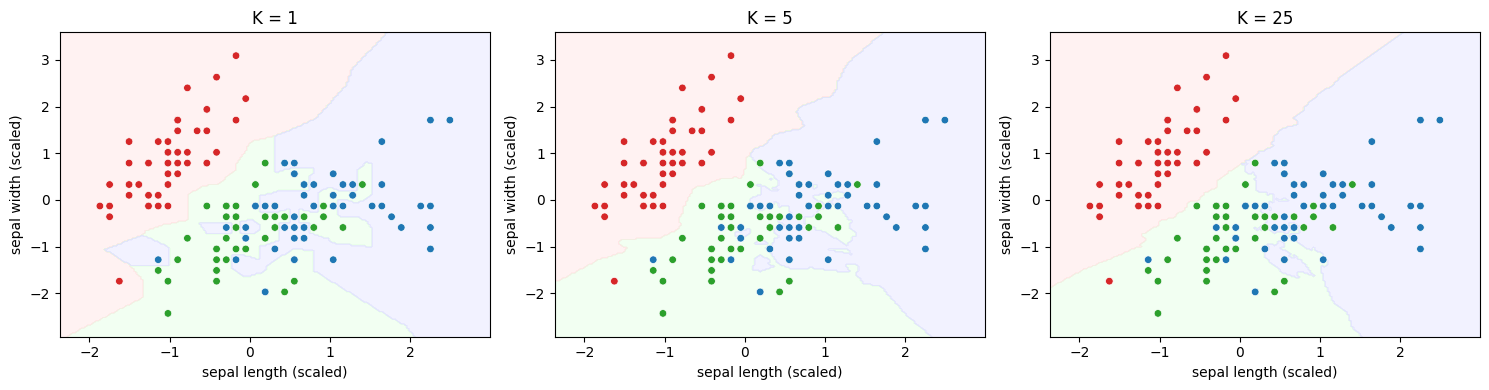

In [5]:
X2 = X[:, :2]                  # sepal length, sepal width
y2 = y
scaler = StandardScaler().fit(X2)
X2s = scaler.transform(X2)

xx, yy = np.meshgrid(
    np.linspace(X2s[:, 0].min() - 0.5, X2s[:, 0].max() + 0.5, 200),
    np.linspace(X2s[:, 1].min() - 0.5, X2s[:, 1].max() + 0.5, 200),
)
grid = np.column_stack([xx.ravel(), yy.ravel()])

ks = [1, 5, 25]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cmap_bg = ListedColormap(['#ffe0e0', '#e0ffe0', '#e0e0ff'])
cmap_pt = ListedColormap(['#d62728', '#2ca02c', '#1f77b4'])
for ax, k in zip(axes, ks):
    preds = knn_predict(X2s, y2, grid, k=k).reshape(xx.shape)
    ax.contourf(xx, yy, preds, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X2s[:, 0], X2s[:, 1], c=y2, cmap=cmap_pt, s=30, edgecolor='white', linewidth=0.5)
    ax.set_title(f'K = {k}')
    ax.set_xlabel('sepal length (scaled)')
    ax.set_ylabel('sepal width (scaled)')
plt.tight_layout()
plt.show()

Observations:

- K=1: every training point owns a Voronoi cell. Boundary is jagged, overfits.
- K=5: smoother boundary, good balance.
- K=25: boundary becomes almost a straight line; underfits in the overlapping region.

## 5. Picking K with cross-validation

best K (5-fold CV) = 5  -> CV accuracy = 0.9667


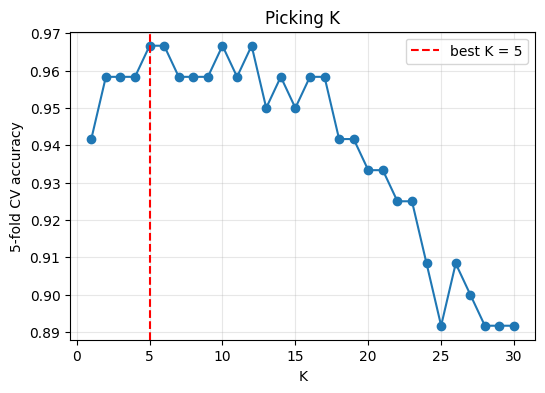

In [6]:
X_train_s = StandardScaler().fit_transform(X_train)
X_test_s  = StandardScaler().fit(X_train).transform(X_test)

ks = list(range(1, 31))
cv_scores = []
for k in ks:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_s, y_train, cv=5)
    cv_scores.append(scores.mean())
best_k = ks[int(np.argmax(cv_scores))]
print(f'best K (5-fold CV) = {best_k}  -> CV accuracy = {max(cv_scores):.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, cv_scores, marker='o')
ax.axvline(best_k, color='red', linestyle='--', label=f'best K = {best_k}')
ax.set_xlabel('K'); ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Picking K')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 6. The scale trap — when one feature dominates

In [7]:
X_lop = X_train.copy()
X_lop[:, 0] = X_lop[:, 0] * 1000.0     # blow up sepal length
X_test_lop = X_test.copy()
X_test_lop[:, 0] *= 1000.0

unscaled_acc = accuracy_score(
    y_test, KNeighborsClassifier(n_neighbors=5).fit(X_lop, y_train).predict(X_test_lop)
)

scaler_fix = StandardScaler().fit(X_lop)
scaled_acc = accuracy_score(
    y_test, KNeighborsClassifier(n_neighbors=5).fit(scaler_fix.transform(X_lop), y_train).predict(scaler_fix.transform(X_test_lop))
)
print(f'lopsided + unscaled accuracy = {unscaled_acc:.4f}')
print(f'lopsided + scaled   accuracy = {scaled_acc:.4f}')

lopsided + unscaled accuracy = 0.6333
lopsided + scaled   accuracy = 0.9333


Without scaling, sepal length's exaggerated scale dominates the distance and KNN essentially ignores the other three features. Scaling restores the balance and recovers full accuracy.

## 7. Confusion matrix and classification report

In [8]:
best_model = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_s, y_train)
y_pred = best_model.predict(X_test_s)
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Confusion matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


## 8. Summary

- KNN is a memorization-based classifier: no parameters, $O(N)$ per prediction.
- K controls smoothness. Pick it by cross-validation.
- Feature scaling is non-negotiable.
- For larger datasets use approximate-NN libraries (e.g. FAISS) — exact KNN scales poorly.

**Next:** `projects/project_02_iris_classification/` — apply this end-to-end.